# Non-tumor RNA-seq reference-space PCA


This notebook compares paired non-tumor biopsy and resection RNA-seq samples
with an external non-tumor reference cohort. It combines compatible count
matrices, retains protein-coding genes, applies VST, visualizes PCA structure,
and measures biopsy/resection displacement in a PCA fitted on all samples.

This workflow is intentionally separate from the tumor/Hoshida notebook: it
uses non-tumor study columns and the distinct `counts_with_class_norm.out`
reference input, and it does not perform Hoshida classification.

**Primary inputs**

- `../counts_080725.out`: paired biopsy/resection featureCounts table.
- `../counts_with_class_norm.out`: external non-tumor reference count table.
- `../sample_mapping_BvR.csv`: paired study sample mapping.
- `../../../ensemble_mappings_biotype.pkl`: Ensembl biotype mapping.

**Key retained decisions**

- Non-tumor RNA-seq columns (`*_nt_transcriptome`) define the paired study cohort.
- Patients M and C and two named external outlier samples are excluded.
- Protein-coding genes with at least 10 counts in at least three samples are retained.


## Manuscript alignment

The final manuscript and revision response were used as the inclusion standard. Alternative visualizations of retained analyses remain acceptable, but unrelated or superseded analytical branches were removed.

**Removed from this notebook**

- No analytical branch removed; the notebook is already restricted to the non-tumor reference-space analysis in Figure 5C-D and Supplementary Figure 7B.

## 1. Environment and imports

Load count-processing, clustering, PCA, plotting, and PyDESeq2 dependencies.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import re
import math
import pickle
from pprint import pprint

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import percentileofscore

import itertools

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.pyplot import gcf
from matplotlib import cm, colors

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 200)

import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

sns.set(font_scale=1.5)
sns.set_style("ticks")

## 2. Select paired non-tumor samples

Load the mapping, retain complete HCC non-tumor pairs, and apply the original patient exclusions.

In [2]:
# New sample mapping with clinical features
meta = pd.read_csv('../sample_mapping_BvR.csv')
# We only do HCC
meta = meta[meta['Tumor diagnosis'] == 'HCC']
# Only take patients were we have all transcriptome samples
rna_cols = ['Biopsy_nt_transcriptome', 'Resection_nt_transcriptome']
meta = meta.dropna(subset=rna_cols)
meta = meta[(meta['Patient ID'] != 'M') & (meta['Patient ID'] != 'M')]
meta = meta[(meta['Patient ID'] != 'C') & (meta['Patient ID'] != 'C')]
meta.head()

,Patient ID,Biopsy_nt_transcriptome,Biopsy_tu_transcriptome,Resection_nt_transcriptome,Resection_tu_transcriptome,Biopsy_nt_proteome,Biopsy_tu_proteome,Resection_nt_protome,Resection_tu_protome,Biopsy_nt_phospho,Biopsy_tu_phospho,Resection_nt_phospho,Resection_tu_phospho,Age,Sex,PreBx_MELD,PreBx_ALAT,PreBx_ASAT,PreBx_GGT,PreBx_AP,PreBx_Albumin,PreBx_Bilirubin,PreBx_Quick,PreBx_Hb,PreBx_Lc,PreBx_Tc,PreBx_CRP,PreBx_AFP,PreOP_MELD,PreOP_ALAT,PreOP_ASAT,PreOP_GGT,PreOP_AP,PreOP_Albumin,PreOP_Bilirubin,PreOP_Quick,PreOP_Hb,PreOP_Lc,PreOP_Tc,PreOP_CRP,PreOP_AFP,CHILD,BCLC,Nr of nodules,Max nodule size,Time between resection and biopsy,Total surgery time = ischemia time,Tumor diagnosis,Biopsy_nt_hepatocyte,Resection_nt_hepatocyte,Biopsy_nt_stroma,Resection_nt_stroma,Biopsy_tu_tumor,Resection_tu_tumor,Biopsy_tu_stroma,Resection_tu_stroma,Biopsy_tu_necrosis,Resection_tu_necrosis,Biopsy_tu_nontumor,Resection_tu_nontumor
3,B,BSSE_QGF_129466,BSSE_QGF_129467,BSSE_QGF_129468,BSSE_QGF_129469,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.0,M,12.0,53.0,55.0,46.0,137.0,36.0,43.0,72.0,141.0,4.0,54.0,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,1,70.0,43.0,NaN,HCC,84.0,94.0,16.0,6.0,86.0,99.0,8.0,0.0,0.0,1.0,5.0,0.0
7,D,BSSE_QGF_182052,BSSE_QGF_182053,BSSE_QGF_182082,BSSE_QGF_182083,011_BR-LF-3_C21,012_BR-LF-3_C21,032_BR-LF-3_C21,033r_BR-LF-3_C21,011_BR-LF-3P_PO4_C21,012_BR-LF-3P_PO4_C21,032_BR-LF-3P_PO4_C21,033_BR-LF-3P_PO4_C21,70.0,F,6.0,29.0,22.0,23.0,82.0,41.0,9.0,94.0,147.0,11.0,254.0,0.3,2.0,6.0,22.0,20.0,22.0,93.0,42.0,11.0,95.0,139.0,11.0,284.0,0.3,NaN,NaN,A,1,23.0,29.0,87.0,HCC,84.0,87.0,16.0,13.0,47.0,97.0,29.0,3.0,0.0,0.0,24.0,0.0
9,E,BSSE_QGF_145476,BSSE_QGF_145477,BSSE_QGF_145478,BSSE_QGF_145479,075_BR-LF-3_C21,076_BR-LF-3_C21,087_BR-LF-3_C21,088_BR-LF-3_C21,075_BR-LF-3P_PO4_C21,076_BR-LF-3P_PO4_C21,087_BR-LF-3P_PO4_C21,088_BR-LF-3P_PO4_C21,79.0,M,6.0,18.0,26.0,167.0,80.0,39.0,10.0,94.0,127.0,5.0,139.0,3.0,12.0,7.0,26.0,28.0,149.0,83.0,38.0,9.0,87.0,139.0,6.0,184.0,2.0,NaN,NaN,A,2,29.0,31.0,149.0,HCC,93.0,90.0,7.0,10.0,61.0,99.0,19.0,1.0,5.0,0.0,15.0,0.0
11,F,BSSE_QGF_145472,BSSE_QGF_145473,BSSE_QGF_145474,BSSE_QGF_145475,077_BR-LF-3_C21,078_BR-LF-3_C21,089_BR-LF-3_C21,090_BR-LF-3_C21,077_BR-LF-3P_PO4_C21,078_BR-LF-3P_PO4_C21,089_BR-LF-3P_PO4_C21,090_BR-LF-3P_PO4_C21,49.0,M,6.0,30.0,29.0,59.0,53.0,38.0,13.0,103.0,161.0,6.0,196.0,1.0,2.0,6.0,25.0,26.0,49.0,56.0,39.0,5.0,115.0,154.0,5.0,209.0,1.0,NaN,NaN,A,1,35.0,11.0,212.0,HCC,99.0,97.0,1.0,3.0,75.0,96.0,10.0,4.0,14.0,0.0,0.0,0.0
15,H,BSSE_QGF_129476,BSSE_QGF_129477,BSSE_QGF_129480,BSSE_QGF_129481,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,69.0,F,11.0,24.0,31.0,23.0,80.0,33.0,25.0,65.0,127.0,4.0,87.0,1.0,NaN,9.0,28.0,35.0,53.0,95.0,36.0,21.0,69.0,117.0,4.0,98.0,NaN,NaN,NaN,A,1,50.0,20.0,64.0,HCC,68.0,82.0,32.0,18.0,98.0,96.0,2.0,4.0,0.0,0.0,0.0,0.0


## 3. Load and verify paired-study counts

Read the paired-study count matrix, standardize identifiers, report missing/extra samples, and retain mapped samples.

In [3]:
# Import data

raw_bvr = pd.read_csv('../counts_080725.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_bvr = raw_bvr.iloc[:,5:]
# Change column names
raw_bvr.columns = raw_bvr.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')

# Check if we have all rna seq samples in the counts table
found = []
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw_bvr.columns:
            found.append(seq_id)
        else:
            print('missing:', seq_id)
            
# Extras
extras = []
for seq_id in raw_bvr.columns:
    if seq_id in found:
        continue
    else:
        print('extra:', seq_id)
        extras.append(seq_id)
raw_bvr = raw_bvr.drop(extras, axis=1)

raw_bvr.head()

extra: BSSE_QGF_129467
extra: BSSE_QGF_129469
extra: BSSE_QGF_129475
extra: BSSE_QGF_129477
extra: BSSE_QGF_129479
extra: BSSE_QGF_129481
extra: BSSE_QGF_145457
extra: BSSE_QGF_145458
extra: BSSE_QGF_145461
extra: BSSE_QGF_145463
extra: BSSE_QGF_145465
extra: BSSE_QGF_145466
extra: BSSE_QGF_145473
extra: BSSE_QGF_145475
extra: BSSE_QGF_145477
extra: BSSE_QGF_145479
extra: BSSE_QGF_145480
extra: BSSE_QGF_145481
extra: BSSE_QGF_182046
extra: BSSE_QGF_182047
extra: BSSE_QGF_182048
extra: BSSE_QGF_182049
extra: BSSE_QGF_182053
extra: BSSE_QGF_182055
extra: BSSE_QGF_182056
extra: BSSE_QGF_182057
extra: BSSE_QGF_182065
extra: BSSE_QGF_182067
extra: BSSE_QGF_182071
extra: BSSE_QGF_182073
extra: BSSE_QGF_182075
extra: BSSE_QGF_182077
extra: BSSE_QGF_182080
extra: BSSE_QGF_182081
extra: BSSE_QGF_182083
extra: BSSE_QGF_182085
extra: BSSE_QGF_182087
extra: BSSE_QGF_182088
extra: BSSE_QGF_182091
extra: BSSE_QGF_182092
extra: BSSE_QGF_182099
extra: BSSE_QGF_182101
extra: BSSE_QGF_182103
extra: BSSE

,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_55728
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,127
ENSG00000279928,1,0,0,1,2,0,1,6,1,0,0,0,0,2,3,1,0,0,1,0,3,0,0,5,0,0,0,0,0,2
ENSG00000228037,13,10,12,24,3,3,2,17,6,2,0,5,2,11,5,5,10,10,8,9,12,5,1,6,0,10,0,5,8,14
ENSG00000142611,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,4
ENSG00000284616,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 4. Load and curate the external reference counts

Read the non-tumor reference matrix, remove duplicate study samples and named reference outliers, then combine matrices.

In [4]:
# Import data

raw_class = pd.read_csv('../counts_with_class_norm.out', skiprows=1, sep='\t', index_col=0)
# Drop gene info
raw_class = raw_class.iloc[:,5:]
# Change column names
raw_class.columns = raw_class.columns.str.split('/').str[-1].str.replace('Aligned.sortedByCoord.out.bam', '')
raw_class.head()

,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34440,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55697,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55728,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,77,129,134,108,134,108,141,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,7,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,21,102,107,105,164,259,126,199,115,127,115,137,121,163,146,112,112,134,353,167
ENSG00000279928,0,5,0,0,2,3,0,0,2,1,0,4,2,2,0,2,3,2,4,0,1,0,1,1,3,3,1,8,4,0,3,0,0,2,1,1,3,0,2,3,4,1,5,1,0,0,0,2,1,0,1,6,8,4,0,0,0,0,0,0,2,0,0,1,2,3,0,6,0,2,1,2,0,0,2,2,0,4,2,2,0,0,0,1,1,0,0,1,0,1,3,0,3,0,2,2,0,1,0,4,1,0,3,1,0,2
ENSG00000228037,5,7,15,13,6,11,10,6,19,8,8,8,4,15,8,6,12,9,9,17,13,11,4,9,11,12,13,14,9,22,19,0,12,9,11,15,7,0,5,14,9,19,11,22,4,8,1,10,9,19,8,24,12,9,21,0,8,15,5,11,9,18,9,11,22,20,3,15,7,18,8,11,6,28,5,5,18,28,23,21,15,5,9,8,2,36,12,10,12,11,15,33,9,22,10,14,17,18,9,10,4,13,16,8,11,4
ENSG00000142611,13,5,6,22,4,0,19,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,1,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,8,7,20,0,20,20,3,16,14,4,4,13,9,21,9,7,16,23,15,2
ENSG00000284616,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [5]:
# Check for duplicates
drop=[]
for group in rna_cols:
    for seq_id in meta[group]:
        if seq_id in raw_class.columns.tolist():
            print(seq_id)
            drop.append(seq_id)
raw_class = raw_class.drop(drop, axis=1)

BSSE_QGF_55728


In [6]:
drop=[]
for col in raw_bvr.columns:
    if col in raw_class.columns.tolist():
        print(col)
        drop.append(col)
        
raw_class = raw_class.drop(drop, axis=1)

In [7]:
# Drop outliers

raw_class = raw_class.drop(['BSSE_QGF_34440', 'BSSE_QGF_55697'], axis=1)

In [8]:
# combine counts tables

raw = pd.concat([raw_bvr, raw_class], axis=1)
raw.head()

,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_55728,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
Geneid,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
ENSG00000160072,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,127,77,129,134,108,134,108,141,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,102,107,105,164,259,126,199,115,115,137,121,163,146,112,112,134,353,167
ENSG00000279928,1,0,0,1,2,0,1,6,1,0,0,0,0,2,3,1,0,0,1,0,3,0,0,5,0,0,0,0,0,2,0,5,0,0,2,3,0,0,2,1,0,4,2,2,0,2,3,2,4,0,1,0,1,1,3,3,1,8,4,0,3,0,0,2,1,1,3,2,3,4,1,5,1,0,0,0,2,1,0,1,6,8,4,0,0,0,0,0,0,2,0,0,1,2,3,0,6,0,2,1,2,0,0,2,2,0,4,2,2,0,0,0,1,1,0,1,0,1,3,0,3,0,2,0,1,0,4,1,0,3,1,0,2
ENSG00000228037,13,10,12,24,3,3,2,17,6,2,0,5,2,11,5,5,10,10,8,9,12,5,1,6,0,10,0,5,8,14,5,7,15,13,6,11,10,6,19,8,8,8,4,15,8,6,12,9,9,17,13,11,4,9,11,12,13,14,9,22,19,0,12,9,11,15,7,5,14,9,19,11,22,4,8,1,10,9,19,8,24,12,9,21,0,8,15,5,11,9,18,9,11,22,20,3,15,7,18,8,11,6,28,5,5,18,28,23,21,15,5,9,8,2,36,10,12,11,15,33,9,22,10,17,18,9,10,4,13,16,8,11,4
ENSG00000142611,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,4,13,5,6,22,4,0,19,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,7,20,0,20,20,3,16,14,4,13,9,21,9,7,16,23,15,2
ENSG00000284616,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [9]:
raw_bvr.shape

(62703, 30)

In [10]:
raw_class.shape

(62703, 103)

In [11]:
raw.shape

(62703, 133)

## 5. Annotate protein-coding genes

Map Ensembl biotypes and retain protein-coding genes.

In [12]:
# Add Gene Biotype Names
with open('../../../ensemble_mappings_biotype.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
    
df_bt = raw.reset_index(names='Geneid').copy()
    
df_bt['Biotype'] = df_bt['Geneid'].map(loaded_dict)
df_bt.Biotype = df_bt.Biotype.replace('', np.nan)
df_bt.index = df_bt.Geneid
df_bt = df_bt.drop('Geneid', axis=1)

In [13]:
# Take only protein coding genes
df_pc = df_bt[df_bt.Biotype == 'protein_coding'].copy()
df_pc = df_pc.drop('Biotype', axis=1)
df_pc.index.name = None
df_pc.shape

(20056, 133)

## 6. Construct combined metadata

Reshape biopsy/resection identifiers and append reference samples labeled as `Class`.

In [14]:
# Create metadata for Deseq
meta_rna = meta.loc[:,['Patient ID', 'Biopsy_nt_transcriptome',
                       'Resection_nt_transcriptome','Age', 'Sex']].copy()
meta_rna = meta_rna.melt(id_vars=['Patient ID', 'Age', 'Sex'],
                         value_vars=['Biopsy_nt_transcriptome',
                                     'Resection_nt_transcriptome',])
meta_rna['Sample_type'] = meta_rna.variable.str.split('_').str[0]
meta_rna = meta_rna.drop('variable', axis=1)
meta_rna = meta_rna.rename({'value':'Seq_id'}, axis=1)
meta_rna.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
0,B,59.0,M,BSSE_QGF_129466,Biopsy
1,D,70.0,F,BSSE_QGF_182052,Biopsy
2,E,79.0,M,BSSE_QGF_145476,Biopsy
3,F,49.0,M,BSSE_QGF_145472,Biopsy
4,H,69.0,F,BSSE_QGF_129476,Biopsy


In [15]:
raw_class.columns

Index(['BSSE_QGF_107000', 'BSSE_QGF_107012', 'BSSE_QGF_107022',
       'BSSE_QGF_107027', 'BSSE_QGF_107036', 'BSSE_QGF_107057',
       'BSSE_QGF_107062', 'BSSE_QGF_34364', 'BSSE_QGF_34368', 'BSSE_QGF_34370',
       ...
       'BSSE_QGF_55734', 'BSSE_QGF_55736', 'BSSE_QGF_55738', 'BSSE_QGF_55746',
       'BSSE_QGF_55750', 'BSSE_QGF_55755', 'BSSE_QGF_55760', 'BSSE_QGF_55762',
       'BSSE_QGF_79903', 'BSSE_QGF_79907'],
      dtype='object', length=103)

In [16]:
metadata = meta_rna.copy()
metadata.index = metadata.Seq_id

metadata = pd.concat([metadata, pd.DataFrame(raw_class.columns, columns=['Seq_id'])])
metadata.Sample_type = metadata.Sample_type.fillna('Class')
metadata.tail()

,Patient ID,Age,Sex,Seq_id,Sample_type
98,NaN,NaN,NaN,BSSE_QGF_55755,Class
99,NaN,NaN,NaN,BSSE_QGF_55760,Class
100,NaN,NaN,NaN,BSSE_QGF_55762,Class
101,NaN,NaN,NaN,BSSE_QGF_79903,Class
102,NaN,NaN,NaN,BSSE_QGF_79907,Class


In [17]:
df_pc.columns

Index(['BSSE_QGF_129466', 'BSSE_QGF_129468', 'BSSE_QGF_129474',
       'BSSE_QGF_129476', 'BSSE_QGF_129478', 'BSSE_QGF_129480',
       'BSSE_QGF_129482', 'BSSE_QGF_145460', 'BSSE_QGF_145462',
       'BSSE_QGF_145472',
       ...
       'BSSE_QGF_55734', 'BSSE_QGF_55736', 'BSSE_QGF_55738', 'BSSE_QGF_55746',
       'BSSE_QGF_55750', 'BSSE_QGF_55755', 'BSSE_QGF_55760', 'BSSE_QGF_55762',
       'BSSE_QGF_79903', 'BSSE_QGF_79907'],
      dtype='object', length=133)

## 7. Low-count filtering and VST

Apply the retained count threshold, align samples, and calculate VST values.

In [18]:
# Filtering

# Create a copy to work on
df_pc_ = df_pc.copy()

# Apply the filter criteria
for col in df_pc_.columns:
    df_pc_[col] = np.where(df_pc_[col] >= 10, True, False)

# Determine which rows have at least `min_trues` True values
df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)

# Store the indices of the rows to keep
keep_indices_ = df_pc_[df_pc_.Keep].index

# Return only the rows that were determined to be kept during fitting
df_pc_ = df_pc.loc[keep_indices_].copy()

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_2948\562405431.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pc_['Keep'] = np.where(df_pc_.sum(axis=1) >= 3, True, False)


In [19]:
df_pc_.columns

Index(['BSSE_QGF_129466', 'BSSE_QGF_129468', 'BSSE_QGF_129474',
       'BSSE_QGF_129476', 'BSSE_QGF_129478', 'BSSE_QGF_129480',
       'BSSE_QGF_129482', 'BSSE_QGF_145460', 'BSSE_QGF_145462',
       'BSSE_QGF_145472',
       ...
       'BSSE_QGF_55734', 'BSSE_QGF_55736', 'BSSE_QGF_55738', 'BSSE_QGF_55746',
       'BSSE_QGF_55750', 'BSSE_QGF_55755', 'BSSE_QGF_55760', 'BSSE_QGF_55762',
       'BSSE_QGF_79903', 'BSSE_QGF_79907'],
      dtype='object', length=133)

In [20]:
metadata.shape

(133, 5)

In [21]:
metadata.Seq_id.duplicated().sum()

np.int64(0)

In [22]:
df_pc_.loc[:,df_pc_.columns.duplicated()]

""
ENSG00000160072
ENSG00000142611
ENSG00000157911
ENSG00000142655
ENSG00000149527
...
ENSG00000276345
ENSG00000275063
ENSG00000277856
ENSG00000271254


In [23]:
# Same sorting
metadata = metadata.sort_values('Seq_id')
metadata.index = metadata.Seq_id
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
Seq_id,,,,,
BSSE_QGF_107000,NaN,NaN,NaN,BSSE_QGF_107000,Class
BSSE_QGF_107012,NaN,NaN,NaN,BSSE_QGF_107012,Class
BSSE_QGF_107022,NaN,NaN,NaN,BSSE_QGF_107022,Class
BSSE_QGF_107027,NaN,NaN,NaN,BSSE_QGF_107027,Class
BSSE_QGF_107036,NaN,NaN,NaN,BSSE_QGF_107036,Class


In [24]:
df_pc_.head()

,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_55728,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
ENSG00000160072,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,127,77,129,134,108,134,108,141,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,102,107,105,164,259,126,199,115,115,137,121,163,146,112,112,134,353,167
ENSG00000142611,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,4,13,5,6,22,4,0,19,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,7,20,0,20,20,3,16,14,4,13,9,21,9,7,16,23,15,2
ENSG00000157911,305,209,290,179,169,93,148,148,105,290,107,104,132,128,310,319,235,71,290,233,129,154,175,230,0,122,178,309,271,121,67,188,133,131,224,103,109,123,339,338,116,185,181,280,240,294,232,208,246,335,366,150,284,274,205,170,240,279,253,175,200,4,213,226,323,270,264,130,308,190,276,281,266,224,202,283,169,220,297,262,215,386,270,181,21,380,142,165,111,104,103,116,123,102,146,205,134,112,170,133,130,118,89,120,129,130,127,122,131,142,173,161,110,130,129,78,70,103,95,123,86,100,77,100,83,80,94,93,130,72,119,170,188
ENSG00000142655,666,512,587,453,301,279,216,286,314,386,208,248,331,351,380,478,448,182,484,342,206,338,313,552,9,583,307,643,509,194,112,370,310,344,416,264,278,116,567,628,268,214,271,409,333,387,497,326,360,472,431,345,273,341,412,301,493,390,372,317,341,6,372,286,448,442,355,286,601,437,367,405,509,304,220,313,293,395,573,451,388,690,476,409,49,501,220,205,370,206,338,201,234,334,454,522,333,296,282,284,253,303,196,304,313,171,273,436,235,361,341,404,208,173,205,206,143,251,173,348,250,214,234,177,208,205,236,208,371,169,218,302,32

In [25]:
df_pc_ = df_pc_.loc[:,metadata.Seq_id]
df_pc_.head()

,BSSE_QGF_107000,BSSE_QGF_107012,BSSE_QGF_107022,BSSE_QGF_107027,BSSE_QGF_107036,BSSE_QGF_107057,BSSE_QGF_107062,BSSE_QGF_129466,BSSE_QGF_129468,BSSE_QGF_129474,BSSE_QGF_129476,BSSE_QGF_129478,BSSE_QGF_129480,BSSE_QGF_129482,BSSE_QGF_145460,BSSE_QGF_145462,BSSE_QGF_145472,BSSE_QGF_145474,BSSE_QGF_145476,BSSE_QGF_145478,BSSE_QGF_182052,BSSE_QGF_182054,BSSE_QGF_182064,BSSE_QGF_182066,BSSE_QGF_182070,BSSE_QGF_182072,BSSE_QGF_182074,BSSE_QGF_182076,BSSE_QGF_182082,BSSE_QGF_182084,BSSE_QGF_182098,BSSE_QGF_182100,BSSE_QGF_182102,BSSE_QGF_182104,BSSE_QGF_182106,BSSE_QGF_182110,BSSE_QGF_34364,BSSE_QGF_34368,BSSE_QGF_34370,BSSE_QGF_34374,BSSE_QGF_34376,BSSE_QGF_34378,BSSE_QGF_34380,BSSE_QGF_34382,BSSE_QGF_34384,BSSE_QGF_34386,BSSE_QGF_34388,BSSE_QGF_34390,BSSE_QGF_34392,BSSE_QGF_34397,BSSE_QGF_34399,BSSE_QGF_34403,BSSE_QGF_34405,BSSE_QGF_34407,BSSE_QGF_34409,BSSE_QGF_34411,BSSE_QGF_34413,BSSE_QGF_34415,BSSE_QGF_34419,BSSE_QGF_34423,BSSE_QGF_34425,BSSE_QGF_34430,BSSE_QGF_34432,BSSE_QGF_34434,BSSE_QGF_34436,BSSE_QGF_34438,BSSE_QGF_34442,BSSE_QGF_34444,BSSE_QGF_34446,BSSE_QGF_34448,BSSE_QGF_34450,BSSE_QGF_34452,BSSE_QGF_34454,BSSE_QGF_34456,BSSE_QGF_34458,BSSE_QGF_34462,BSSE_QGF_34464,BSSE_QGF_34466,BSSE_QGF_34468,BSSE_QGF_34479,BSSE_QGF_34481,BSSE_QGF_34482,BSSE_QGF_34485,BSSE_QGF_34494,BSSE_QGF_35689,BSSE_QGF_35697,BSSE_QGF_35703,BSSE_QGF_54952,BSSE_QGF_54953,BSSE_QGF_54954,BSSE_QGF_54956,BSSE_QGF_54960,BSSE_QGF_54962,BSSE_QGF_54966,BSSE_QGF_54971,BSSE_QGF_54972,BSSE_QGF_54974,BSSE_QGF_54978,BSSE_QGF_54983,BSSE_QGF_54991,BSSE_QGF_54993,BSSE_QGF_54996,BSSE_QGF_54998,BSSE_QGF_55003,BSSE_QGF_55005,BSSE_QGF_55011,BSSE_QGF_55015,BSSE_QGF_55018,BSSE_QGF_55023,BSSE_QGF_55025,BSSE_QGF_55027,BSSE_QGF_55033,BSSE_QGF_55039,BSSE_QGF_55043,BSSE_QGF_55703,BSSE_QGF_55705,BSSE_QGF_55707,BSSE_QGF_55711,BSSE_QGF_55718,BSSE_QGF_55720,BSSE_QGF_55724,BSSE_QGF_55726,BSSE_QGF_55728,BSSE_QGF_55734,BSSE_QGF_55736,BSSE_QGF_55738,BSSE_QGF_55746,BSSE_QGF_55750,BSSE_QGF_55755,BSSE_QGF_55760,BSSE_QGF_55762,BSSE_QGF_79903,BSSE_QGF_79907
ENSG00000160072,77,129,134,108,134,108,141,298,285,158,289,169,113,154,165,183,69,41,70,135,132,200,240,286,68,192,186,116,181,271,505,6,312,201,261,445,108,397,317,171,257,162,321,197,263,247,175,189,213,549,239,217,226,273,155,240,312,208,268,188,4,225,68,304,416,236,122,336,192,306,189,329,83,203,144,166,185,394,153,352,326,453,233,13,223,128,250,196,152,91,96,150,167,269,299,223,86,193,211,240,148,111,162,120,74,211,151,107,324,172,184,135,123,195,102,107,105,164,259,126,199,115,127,115,137,121,163,146,112,112,134,353,167
ENSG00000142611,13,5,6,22,4,0,19,40,50,18,92,19,14,4,35,31,4,3,0,0,6,1,1,18,5,4,17,3,14,8,28,0,19,13,13,5,2,22,34,14,55,11,19,25,21,23,6,6,23,43,6,28,13,38,22,14,45,58,32,8,0,20,12,62,34,30,17,88,41,49,12,97,9,33,11,16,28,13,8,69,73,8,14,8,11,18,8,32,13,11,10,9,16,29,5,35,4,11,62,35,5,10,0,7,19,44,0,2,16,0,3,9,12,15,7,20,0,20,20,3,16,14,4,4,13,9,21,9,7,16,23,15,2
ENSG00000157911,67,188,133,131,224,103,109,305,209,290,179,169,93,148,148,105,290,107,104,132,128,310,319,235,71,290,233,129,154,175,230,0,122,178,309,271,123,339,338,116,185,181,280,240,294,232,208,246,335,366,150,284,274,205,170,240,279,253,175,200,4,213,226,323,270,264,130,308,190,276,281,266,224,202,283,169,220,297,262,215,386,270,181,21,380,142,165,111,104,103,116,123,102,146,205,134,112,170,133,130,118,89,120,129,130,127,122,131,142,173,161,110,130,129,78,70,103,95,123,86,100,77,121,100,83,80,94,93,130,72,119,170,188
ENSG00000142655,112,370,310,344,416,264,278,666,512,587,453,301,279,216,286,314,386,208,248,331,351,380,478,448,182,484,342,206,338,313,552,9,583,307,643,509,116,567,628,268,214,271,409,333,387,497,326,360,472,431,345,273,341,412,301,493,390,372,317,341,6,372,286,448,442,355,286,601,437,367,405,509,304,220,313,293,395,573,451,388,690,476,409,49,501,220,205,370,206,338,201,234,334,454,522,333,296,282,284,253,303,196,304,313,171,273,436,235,361,341,404,208,173,205,206,143,251,173,348,250,214,234,194,177,208,205,236,208,371,169,218,302,32

In [26]:
for col in df_pc_.columns:
    if col in metadata.Seq_id.tolist():
        continue
    else:
        print(col)

In [27]:
for col in metadata.Seq_id:
    if col in df_pc_.columns.tolist():
        continue
    else:
        print(col)

In [28]:
# Perform vst normalization

# Create and fit the DESeq2 dataset
dds = DeseqDataSet(
    counts=df_pc_.T,
    metadata=metadata,
    # design_factors=[Sex + batch + patient_id], # Sex as covariate
    design="~ Sample_type",
    refit_cooks=True,
    inference=DefaultInference(n_cpus=4),
)
dds.fit_size_factors()
dds.vst_fit()

transformed_counts = dds.vst_transform(counts=df_pc_.T)
transformed_counts = pd.DataFrame(
    transformed_counts, index=df_pc_.T.index, columns=df_pc_.T.columns
)
df_vst = transformed_counts.T

Fitting size factors...
... done in 0.18 seconds.

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization
Using None as control genes, passed at DeseqDataSet initialization


... done in 0.17 seconds.

Fitting dispersions...
... done in 14.96 seconds.



## 8. Exploratory PCA

Scale the VST matrix, fit a 10-component PCA, and visualize sample type and patient structure.

In [29]:
metadata.head()

,Patient ID,Age,Sex,Seq_id,Sample_type
Seq_id,,,,,
BSSE_QGF_107000,NaN,NaN,NaN,BSSE_QGF_107000,Class
BSSE_QGF_107012,NaN,NaN,NaN,BSSE_QGF_107012,Class
BSSE_QGF_107022,NaN,NaN,NaN,BSSE_QGF_107022,Class
BSSE_QGF_107027,NaN,NaN,NaN,BSSE_QGF_107027,Class
BSSE_QGF_107036,NaN,NaN,NaN,BSSE_QGF_107036,Class


In [30]:
# Subset classification samples

df_class = df_vst.loc[:,metadata[metadata.Sample_type == 'Class'].index].copy()
df_bvr = df_vst.loc[:,metadata[metadata.Sample_type != 'Class'].index].copy()

In [31]:
# scaled data

scaler = StandardScaler()
scaler.fit(df_class.T)
scaled_data_class = scaler.transform(df_class.T)
scaled_data = scaler.transform(df_vst.T)


In [32]:
pca = PCA(n_components=10)
pca.fit(scaled_data_class)
projections = pca.transform(scaled_data)

In [33]:
hue_order=['Biopsy', 'Resection', 'Class']

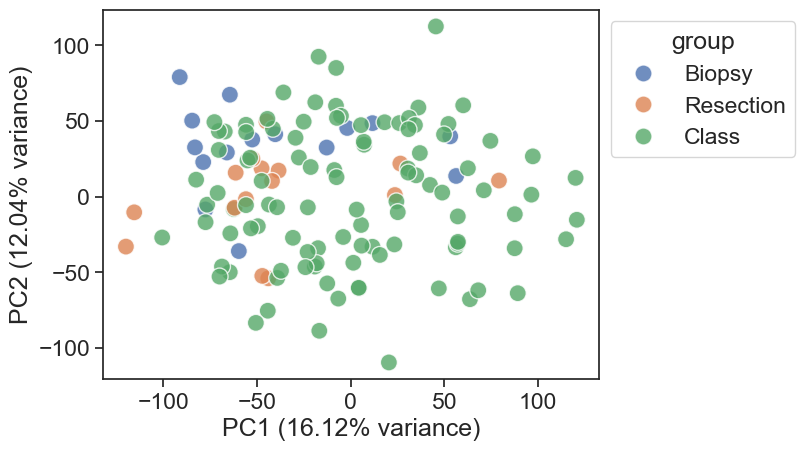

C:\Users\Fredrik\AppData\Local\Temp\ipykernel_2948\2408174255.py:21: UserWarning: 
The palette list has fewer values (1) than needed (15) and will cycle, which may produce an uninterpretable plot.
  h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)


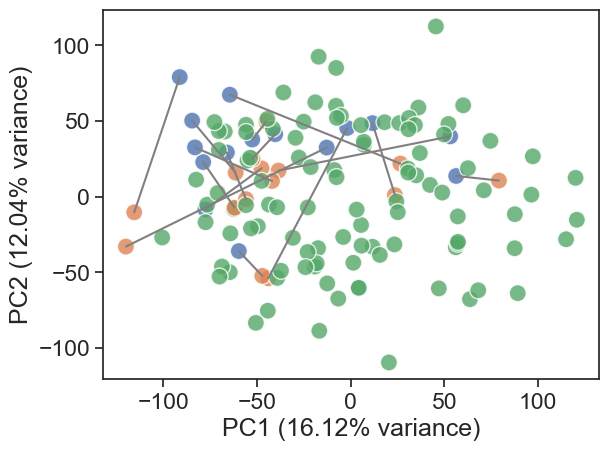

In [34]:
df_pca = pd.DataFrame(projections, columns=[f'PC{x}' for x in range(1,11)], index=df_vst.columns)
df_pca['group'] = metadata.Sample_type
df_pca['patient_id'] = metadata['Patient ID'].astype(str)

# Overview
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order = hue_order)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
xlim = g.get_xlim()
ylim = g.get_ylim()
plt.savefig('PCA_classification_norm.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


# Patients
fig, ax = plt.subplots()
g = sns.scatterplot(df_pca, x='PC1', y='PC2', hue='group', ax=ax, s=150, alpha=0.8, hue_order=hue_order)
h = sns.lineplot(df_pca[df_pca.patient_id != 'nan'], x='PC1', y='PC2', hue='patient_id', palette=sns.color_palette(['gray']), ax=ax)
plt.legend([],[], frameon=False)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.savefig('PCA_classification_pat_norm.pdf', bbox_inches='tight', dpi=300)
plt.show()
plt.close()


## 9. All-sample PCA and patient-blocked test

Fit PCA using reference and study samples, calculate the collection-method effect, and enumerate within-patient label swaps.

In [35]:
def fit_all_sample_pca(
    ref_expr,
    study_expr,
    n_top_genes=500,
    n_pcs=10,
    random_state=1,
):
    """
    Fits PCA on all samples:
        Class reference + study Biopsy + study Resection

    Inputs are samples x genes.

    Returns:
        all_scores
        ref_scores_allspace
        study_scores_allspace
        pca
        scaler
        top_genes
    """

    common_genes = ref_expr.columns.intersection(study_expr.columns)

    ref_common = ref_expr.loc[:, common_genes]
    study_common = study_expr.loc[:, common_genes]

    all_expr = pd.concat(
        [ref_common, study_common],
        axis=0
    )

    n_top_genes = min(n_top_genes, all_expr.shape[1])

    top_genes = (
        all_expr.var(axis=0)
        .sort_values(ascending=False)
        .head(n_top_genes)
        .index
    )

    scaler = StandardScaler(with_mean=True, with_std=True)

    all_scaled = scaler.fit_transform(all_expr.loc[:, top_genes])

    max_pcs = min(n_pcs, all_scaled.shape[0] - 1, all_scaled.shape[1])

    pca = PCA(n_components=max_pcs, random_state=random_state)

    all_scores_array = pca.fit_transform(all_scaled)

    pc_cols = [f"PC{i+1}" for i in range(max_pcs)]

    all_scores = pd.DataFrame(
        all_scores_array,
        index=all_expr.index,
        columns=pc_cols,
    )

    ref_scores_allspace = all_scores.loc[ref_expr.index]
    study_scores_allspace = all_scores.loc[study_expr.index]

    return (
        all_scores,
        ref_scores_allspace,
        study_scores_allspace,
        pca,
        scaler,
        top_genes,
    )

def exhaustive_patient_blocked_collection_test(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Exact patient-blocked permutation test for paired Biopsy/Resection PCA scores.
    Enumerates all 2^n within-patient label swaps.

    Suitable when n_pairs is modest, e.g. <= 20.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    keep_samples = []
    patients_ordered = []

    for patient, m in meta.groupby(patient_col):
        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) == 1 and len(resection_samples) == 1:
            keep_samples.extend([biopsy_samples[0], resection_samples[0]])
            patients_ordered.append(patient)

    meta = meta.loc[keep_samples].copy()
    Y = scores.loc[keep_samples, pc_cols].values

    patient_dummies = pd.get_dummies(meta[patient_col], drop_first=False)
    X_patient = patient_dummies.values.astype(float)

    collection_observed = (
        meta[sample_type_col].values == resection_label
    ).astype(float).reshape(-1, 1)

    def rss_multivariate_lm(Y, X):
        beta, *_ = np.linalg.lstsq(X, Y, rcond=None)
        resid = Y - X @ beta
        rss = np.sum(resid ** 2)
        rank = np.linalg.matrix_rank(X)
        df_resid = Y.shape[0] - rank
        return rss, df_resid, rank

    rss_patient, df_patient, rank_patient = rss_multivariate_lm(Y, X_patient)

    X_full_observed = np.column_stack([X_patient, collection_observed])
    rss_full_obs, df_full, rank_full = rss_multivariate_lm(Y, X_full_observed)

    ss_collection_obs = rss_patient - rss_full_obs
    partial_R2_obs = ss_collection_obs / rss_patient

    n_pairs = len(patients_ordered)

    perm_R2 = []

    # Precompute sample indices for each patient
    patient_to_indices = {
        patient: np.where(meta[patient_col].values == patient)[0]
        for patient in patients_ordered
    }

    for swap_pattern in itertools.product([0, 1], repeat=n_pairs):

        collection_perm = collection_observed.copy()

        for patient, swap in zip(patients_ordered, swap_pattern):
            if swap == 1:
                idx = patient_to_indices[patient]
                collection_perm[idx] = 1 - collection_perm[idx]

        X_perm = np.column_stack([X_patient, collection_perm])
        rss_perm_full, _, _ = rss_multivariate_lm(Y, X_perm)

        ss_perm_collection = rss_patient - rss_perm_full
        perm_R2.append(ss_perm_collection / rss_patient)

    perm_R2 = np.array(perm_R2)

    exact_p = np.mean(perm_R2 >= partial_R2_obs - 1e-12)

    result = {
        "n_pairs": n_pairs,
        "n_samples": meta.shape[0],
        "n_pcs": len(pc_cols),
        "observed_partial_R2": partial_R2_obs,
        "observed_partial_R2_percent": 100 * partial_R2_obs,
        "exact_permutation_p_value": exact_p,
        "n_total_permutations": len(perm_R2),
        "n_permutations_ge_observed": int(np.sum(perm_R2 >= partial_R2_obs - 1e-12)),
        "max_permuted_partial_R2": np.max(perm_R2),
        "max_permuted_partial_R2_percent": 100 * np.max(perm_R2),
    }

    return result, perm_R2

def matched_pair_distances(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates matched biopsy-to-resection Euclidean distances
    for each patient in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        dist = np.linalg.norm(
            scores.loc[b, pc_cols].values -
            scores.loc[r, pc_cols].values
        )

        rows.append({
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "matched_distance": dist,
        })

    return pd.DataFrame(rows)    

def paired_distance_magnitude(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    """
    Calculates paired biopsy-to-resection distances and patient centroids
    in PCA space.
    """

    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    pair_rows = []
    centroid_rows = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        b_vec = scores.loc[b, pc_cols].values.astype(float)
        r_vec = scores.loc[r, pc_cols].values.astype(float)

        diff = r_vec - b_vec
        dist = np.linalg.norm(diff)

        centroid = (b_vec + r_vec) / 2

        row = {
            patient_col: patient,
            "biopsy_sample": b,
            "resection_sample": r,
            "n_pcs": len(pc_cols),
            "paired_distance": dist,
        }

        for pc, value in zip(pc_cols, diff):
            row[f"{pc}_resection_minus_biopsy"] = value

        pair_rows.append(row)

        centroid_rows.append(
            pd.Series(centroid, index=pc_cols, name=patient)
        )

    paired_distances = pd.DataFrame(pair_rows)
    patient_centroids = pd.DataFrame(centroid_rows)

    return paired_distances, patient_centroids

def paired_displacement_direction(
    scores,
    meta,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    biopsy_label="Biopsy",
    resection_label="Resection",
    pc_cols=None,
):
    if pc_cols is None:
        pc_cols = [c for c in scores.columns if c.startswith("PC")]

    meta = meta.loc[scores.index].copy()

    diffs = []

    for patient, m in meta.groupby(patient_col):

        biopsy_samples = m.index[m[sample_type_col] == biopsy_label].tolist()
        resection_samples = m.index[m[sample_type_col] == resection_label].tolist()

        if len(biopsy_samples) != 1 or len(resection_samples) != 1:
            continue

        b = biopsy_samples[0]
        r = resection_samples[0]

        diff = scores.loc[r, pc_cols] - scores.loc[b, pc_cols]
        diff.name = patient
        diffs.append(diff)

    diffs = pd.DataFrame(diffs)

    direction = pd.DataFrame({
        "mean_resection_minus_biopsy": diffs.mean(axis=0),
        "median_resection_minus_biopsy": diffs.median(axis=0),
        "sd": diffs.std(axis=0),
    })

    direction["abs_mean"] = direction["mean_resection_minus_biopsy"].abs()

    return diffs, direction.sort_values("abs_mean", ascending=False)

In [36]:
# Your expression matrix: genes x samples
# Replace this with your actual dataframe name
expr = df_vst.copy()

# Metadata from your screenshot
meta = metadata.copy()

sample_col = "Seq_id"
patient_col = "Patient ID"
sample_type_col = "Sample_type"

REF_LABEL = "Class"
BIOPSY_LABEL = "Biopsy"
RESECTION_LABEL = "Resection"

N_TOP_GENES = 500
N_PCS = 10
N_PERM = 9999
RANDOM_STATE = 1

In [37]:
# Make sure metadata index is Seq_id
if meta.index.name != sample_col:
    meta = meta.set_index(sample_col, drop=False)

# Remove accidental whitespace
meta[sample_type_col] = meta[sample_type_col].astype(str).str.strip()
meta[sample_col] = meta[sample_col].astype(str).str.strip()

expr.columns = expr.columns.astype(str).str.strip()
expr.index = expr.index.astype(str).str.strip()

# Keep only samples present in both expression matrix and metadata
common_samples = expr.columns.intersection(meta.index)

expr = expr.loc[:, common_samples]
meta = meta.loc[common_samples]

print(expr.shape)
print(meta[sample_type_col].value_counts())

(16391, 133)
Sample_type
Class        103
Biopsy        15
Resection     15
Name: count, dtype: int64


In [38]:
ref_samples = meta.index[meta[sample_type_col] == REF_LABEL]
study_samples = meta.index[meta[sample_type_col].isin([BIOPSY_LABEL, RESECTION_LABEL])]

# Convert from genes x samples to samples x genes
ref_expr = expr.loc[:, ref_samples].T
study_expr = expr.loc[:, study_samples].T

study_meta = meta.loc[study_samples].copy()
ref_meta = meta.loc[ref_samples].copy()

print("Reference expression:", ref_expr.shape)
print("Study expression:", study_expr.shape)
print(study_meta[sample_type_col].value_counts())

Reference expression: (103, 16391)
Study expression: (30, 16391)
Sample_type
Biopsy       15
Resection    15
Name: count, dtype: int64


In [39]:
(
    all_scores,
    ref_scores_allspace,
    study_scores_allspace,
    all_pca,
    all_scaler,
    all_top_genes,
) = fit_all_sample_pca(
    ref_expr=ref_expr,
    study_expr=study_expr,
    n_top_genes=N_TOP_GENES,
    n_pcs=N_PCS,
    random_state=RANDOM_STATE,
)

pd.Series(
    all_pca.explained_variance_ratio_,
    index=all_scores.columns,
    name="explained_variance_ratio",
)

PC1     0.268040
PC2     0.099441
PC3     0.069616
PC4     0.065570
PC5     0.042771
PC6     0.030326
PC7     0.025992
PC8     0.021984
PC9     0.021040
PC10    0.017778
Name: explained_variance_ratio, dtype: float64

In [40]:
allspace_test_result, allspace_perm_R2 = exhaustive_patient_blocked_collection_test(
    scores=study_scores_allspace,
    meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=study_scores_allspace.columns.tolist(),
)

allspace_test_result

{'n_pairs': 15,
 'n_samples': 30,
 'n_pcs': 10,
 'observed_partial_R2': np.float64(0.6461816122366971),
 'observed_partial_R2_percent': np.float64(64.61816122366972),
 'exact_permutation_p_value': np.float64(6.103515625e-05),
 'n_total_permutations': 32768,
 'n_permutations_ge_observed': 2,
 'max_permuted_partial_R2': np.float64(0.6461816122366971),
 'max_permuted_partial_R2_percent': np.float64(64.61816122366972)}

In [41]:
test_out = pd.DataFrame().from_dict(allspace_test_result, orient='index')
test_out.to_csv('Permutation_class_norm.csv')
test_out

,0
n_pairs,15.000000
n_samples,30.000000
n_pcs,10.000000
observed_partial_R2,0.646182
observed_partial_R2_percent,64.618161
exact_permutation_p_value,0.000061
n_total_permutations,32768.000000
n_permutations_ge_observed,2.000000
max_permuted_partial_R2,0.646182
max_permuted_partial_R2_percent,64.618161


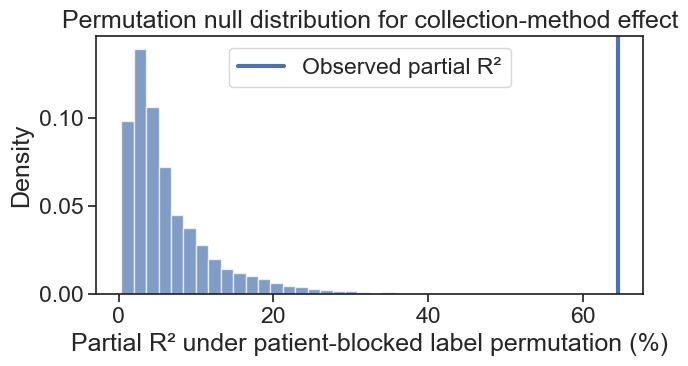

In [42]:
#observed_F = joint_test_result["F"]
observed_partial_R2 = allspace_test_result["observed_partial_R2"]

plt.figure(figsize=(7, 4))

plt.hist(
    allspace_perm_R2 * 100,
    bins=40,
    alpha=0.7,
    density=True,
)

plt.axvline(
    observed_partial_R2 * 100,
    linewidth=3,
    label="Observed partial R²",
)

plt.xlabel("Partial R² under patient-blocked label permutation (%)")
plt.ylabel("Density")
plt.title("Permutation null distribution for collection-method effect")
plt.legend()
plt.tight_layout()
plt.savefig('Perm_joint_pca_class_norm.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 10. All-sample PCA visualization

Plot the reference cohort together with paired biopsy/resection samples.

In [43]:
def plot_all_sample_pca(
    all_scores,
    meta,
    study_meta,
    pca,
    patient_col="Patient ID",
    sample_type_col="Sample_type",
    title="All-sample PCA",
):
    plt.figure(figsize=(7, 6))

    meta_all = meta.loc[all_scores.index].copy()

    # Plot all samples by Sample_type
    for sample_type, idx in meta_all.groupby(sample_type_col).groups.items():
        idx = list(idx)

        alpha = 0.25 if sample_type == REF_LABEL else 0.85
        size = 25 if sample_type == REF_LABEL else 55

        plt.scatter(
            all_scores.loc[idx, "PC1"],
            all_scores.loc[idx, "PC2"],
            label=sample_type,
            alpha=alpha,
            s=size,
        )

    # Connect study biopsy/resection pairs
    for patient, m in study_meta.groupby(patient_col):
        sample_ids = m.index.tolist()

        if len(sample_ids) >= 2:
            plt.plot(
                all_scores.loc[sample_ids, "PC1"],
                all_scores.loc[sample_ids, "PC2"],
                alpha=0.5,
                color='grey',
                linewidth=1,
            )

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig('PCA_class_fitted_on_all_norm.pdf', dpi=300, bbox_inches='tight')
    plt.show()

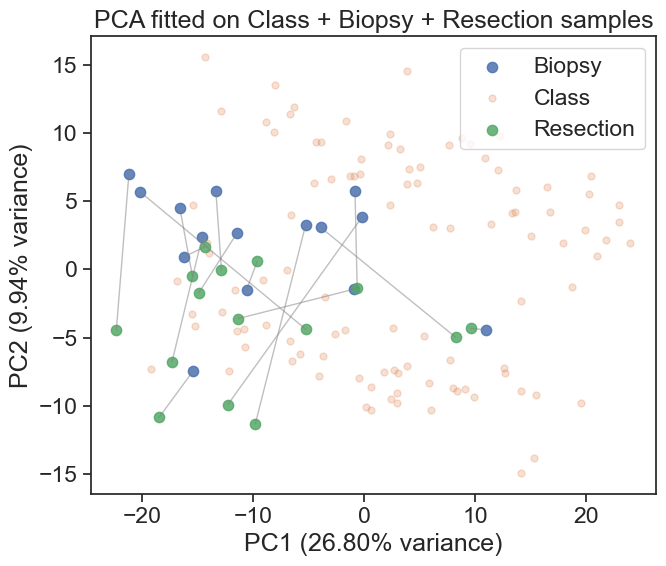

In [44]:
plot_all_sample_pca(
    all_scores=all_scores,
    meta=meta,
    pca=all_pca,
    study_meta=study_meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    title="PCA fitted on Class + Biopsy + Resection samples",
)

## 11. Paired-distance benchmarking

Quantify within-patient biopsy/resection distances and compare them with between-reference distances.

In [45]:
K = 10
pc_cols = [f"PC{i+1}" for i in range(K)]

# scores,
# meta,
# patient_col="Patient ID",
# sample_type_col="Sample_type",
# biopsy_label="Biopsy",
# resection_label="Resection",

paired_distances, patient_centroids = paired_distance_magnitude(
    scores=all_scores,
    meta=meta,
    patient_col=patient_col,
    sample_type_col=sample_type_col,
    biopsy_label=BIOPSY_LABEL,
    resection_label=RESECTION_LABEL,
    pc_cols=pc_cols,
)

paired_distances

,Patient ID,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy
0,B,BSSE_QGF_129466,BSSE_QGF_129468,10,21.199955,12.141800,-8.036541,10.028955,7.149708,1.468288,5.944401,2.158227,-1.513564,-3.012651,5.675725
1,D,BSSE_QGF_182052,BSSE_QGF_182082,10,15.240130,0.954945,2.067895,10.865677,6.452300,3.480780,6.085709,0.465621,-0.737859,-3.164557,2.729650
2,E,BSSE_QGF_145476,BSSE_QGF_145478,10,16.458509,1.824991,0.711970,12.392676,6.147746,3.354551,7.075918,0.585781,1.004304,-3.126519,1.795355
3,F,BSSE_QGF_145472,BSSE_QGF_145474,10,19.893201,-1.131696,-11.427519,9.275599,7.195064,4.442053,8.733405,-0.353341,-0.477325,-4.984199,2.205832
4,H,BSSE_QGF_129476,BSSE_QGF_129480,10,15.920978,-10.462599,-2.162628,4.885311,-0.595998,7.057453,4.550904,0.396132,-3.413094,-4.219721,3.870734
5,I,BSSE_QGF_182072,BSSE_QGF_182106,10,17.103306,0.508163,-5.837300,11.414544,7.045060,4.090672,6.042530,-1.049154,-0.177994,-4.887193,-0.057085
6,J,BSSE_QGF_182064,BSSE_QGF_182098,10,24.811405,14.934403,-10.076875,11.362137,10.366836,2.965717,3.119080,-2.487082,0.365497,-5.294237,-1.258701
7,K,BSSE_QGF_129474,BSSE_QGF_129478,10,23.518561,-4.542378,-14.599981,11.290456,8.028541,2.156635,9.692615,-1.069383,2.169944,-4.678139,-1.031073
8,L,BSSE_QGF_145460,BSSE_QGF_145462,10,8.242684,-1.346772,0.112925,2.220159,5.204105,2.798205,0.839027,-2.189756,0.794302,-4.244068,-1.459968
9,N,BSSE_QGF_182054,BSSE_QGF_182084,10,17.743915,1.141829,-5.015321,13.928873,5.625554,2.334800,5.631044,0.705388,0.099666,-4.578465,2.024636


In [46]:
between_patient_centroid_distances = pdist(
    patient_centroids.loc[:, pc_cols].values,
    metric="euclidean",
)

median_paired_distance = paired_distances["paired_distance"].median()
median_between_patient_distance = np.median(between_patient_centroid_distances)

magnitude_ratio = median_paired_distance / median_between_patient_distance

paired_distance_percentile = percentileofscore(
    between_patient_centroid_distances,
    median_paired_distance,
    kind="rank",
)

magnitude_summary = pd.DataFrame({
    "n_pairs": [paired_distances.shape[0]],
    "n_pcs": [K],
    "median_paired_distance": [median_paired_distance],
    "mean_paired_distance": [paired_distances["paired_distance"].mean()],
    "median_between_patient_centroid_distance": [median_between_patient_distance],
    "paired_to_between_patient_distance_ratio": [magnitude_ratio],
    "median_paired_distance_percentile_vs_between_patient": [paired_distance_percentile],
})

magnitude_summary

,n_pairs,n_pcs,median_paired_distance,mean_paired_distance,median_between_patient_centroid_distance,paired_to_between_patient_distance_ratio,median_paired_distance_percentile_vs_between_patient
0,15,10,17.743915,18.438294,18.879054,0.939873,37.142857


In [47]:
paired_distances["percentile_vs_between_patient_centroids"] = [
    percentileofscore(
        between_patient_centroid_distances,
        d,
        kind="rank",
    )
    for d in paired_distances["paired_distance"]
]

paired_distances["ratio_to_median_between_patient_distance"] = (
    paired_distances["paired_distance"] / median_between_patient_distance
)

paired_distances

,Patient ID,biopsy_sample,resection_sample,n_pcs,paired_distance,PC1_resection_minus_biopsy,PC2_resection_minus_biopsy,PC3_resection_minus_biopsy,PC4_resection_minus_biopsy,PC5_resection_minus_biopsy,PC6_resection_minus_biopsy,PC7_resection_minus_biopsy,PC8_resection_minus_biopsy,PC9_resection_minus_biopsy,PC10_resection_minus_biopsy,percentile_vs_between_patient_centroids,ratio_to_median_between_patient_distance
0,B,BSSE_QGF_129466,BSSE_QGF_129468,10,21.199955,12.141800,-8.036541,10.028955,7.149708,1.468288,5.944401,2.158227,-1.513564,-3.012651,5.675725,67.619048,1.122935
1,D,BSSE_QGF_182052,BSSE_QGF_182082,10,15.240130,0.954945,2.067895,10.865677,6.452300,3.480780,6.085709,0.465621,-0.737859,-3.164557,2.729650,20.952381,0.807251
2,E,BSSE_QGF_145476,BSSE_QGF_145478,10,16.458509,1.824991,0.711970,12.392676,6.147746,3.354551,7.075918,0.585781,1.004304,-3.126519,1.795355,28.571429,0.871787
3,F,BSSE_QGF_145472,BSSE_QGF_145474,10,19.893201,-1.131696,-11.427519,9.275599,7.195064,4.442053,8.733405,-0.353341,-0.477325,-4.984199,2.205832,59.047619,1.053718
4,H,BSSE_QGF_129476,BSSE_QGF_129480,10,15.920978,-10.462599,-2.162628,4.885311,-0.595998,7.057453,4.550904,0.396132,-3.413094,-4.219721,3.870734,24.761905,0.843314
5,I,BSSE_QGF_182072,BSSE_QGF_182106,10,17.103306,0.508163,-5.837300,11.414544,7.045060,4.090672,6.042530,-1.049154,-0.177994,-4.887193,-0.057085,32.380952,0.905941
6,J,BSSE_QGF_182064,BSSE_QGF_182098,10,24.811405,14.934403,-10.076875,11.362137,10.366836,2.965717,3.119080,-2.487082,0.365497,-5.294237,-1.258701,82.857143,1.314229
7,K,BSSE_QGF_129474,BSSE_QGF_129478,10,23.518561,-4.542378,-14.599981,11.290456,8.028541,2.156635,9.692615,-1.069383,2.169944,-4.678139,-1.031073,78.095238,1.245749
8,L,BSSE_QGF_145460,BSSE_QGF_145462,10,8.242684,-1.346772,0.112925,2.220159,5.204105,2.798205,0.839027,-2.189756,0.794302,-4.244068,-1.459968,0.952381,0.436605
9,N,BSSE_QGF_182054,BSSE_QGF_182084,10,17.743915,1.141829,-5.015321,13.928873,5.625554,2.334800,5.631044,0.705388,0.099666,-4.578465,2.024636,37.142857,0.939873


In [48]:
patient_col = 'Patient ID'
distance_col = 'paired_distance'

# Copy and sort patient-level distances
plot_df = paired_distances[[patient_col, distance_col]].copy()
plot_df = plot_df.sort_values(distance_col, ascending=True).reset_index(drop=True)

# Summary stats for paired distances
paired_median = plot_df[distance_col].median()
paired_q1 = plot_df[distance_col].quantile(0.25)
paired_q3 = plot_df[distance_col].quantile(0.75)

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)
between_q1 = np.quantile(between_patient_centroid_distances, 0.25)
between_q3 = np.quantile(between_patient_centroid_distances, 0.75)

In [49]:
plot_df_norm = plot_df.copy()
plot_df_norm["relative_distance"] = plot_df_norm[distance_col] / between_median
plot_df_norm = plot_df_norm.sort_values("relative_distance", ascending=True).reset_index(drop=True)

In [50]:
plot_df_norm.mean(numeric_only=True)

paired_distance      18.438294
relative_distance     0.976653
dtype: float64

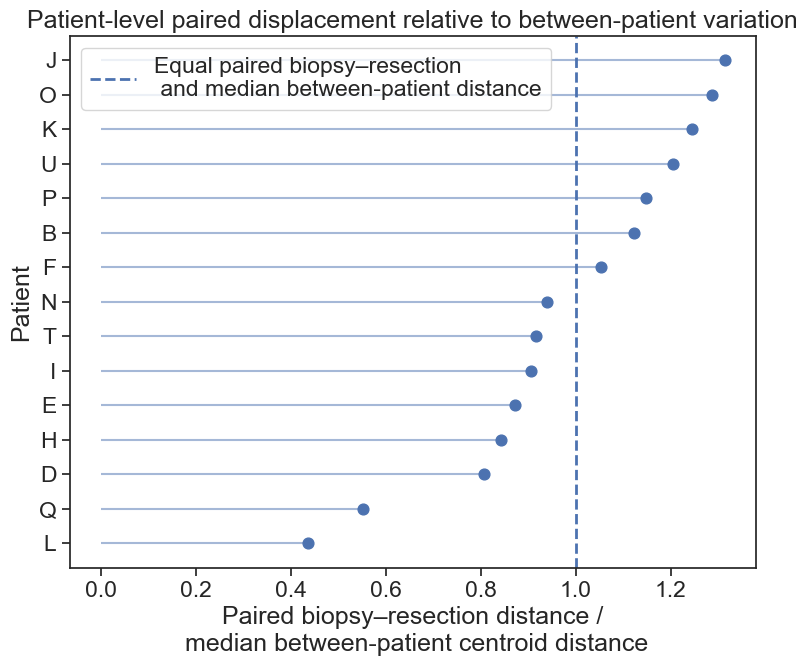

In [88]:
plt.figure(figsize=(8, 7))

y = np.arange(len(plot_df_norm))

# Summary stats for paired distances
paired_median = plot_df_norm[distance_col].median()

# Summary stats for between-patient centroid distances
between_median = np.median(between_patient_centroid_distances)

for yi, x in zip(y, plot_df_norm["relative_distance"]):
    plt.hlines(y=yi, xmin=0, xmax=x, linewidth=1.5, alpha=0.5)

plt.scatter(plot_df_norm["relative_distance"], y, s=60, zorder=3)

plt.axvline(1.0, linestyle="--", linewidth=2, label="Equal paired biopsy–resection \n and median between-patient distance")
#plt.axvline(0.5, linestyle=":", linewidth=1.5)
#plt.axvline(0.25, linestyle=":", linewidth=1.5)

# plt.axvline(
#     paired_median,
#     linewidth=1.5,
#     label="Median paired biopsy–resection distance"
# )

# plt.axvline(
#     between_median,
#     linewidth=1.5,
#     label="Median between-patient distance"
# )

plt.yticks(y, plot_df_norm[patient_col])
plt.xlabel("Paired biopsy–resection distance /\n median between-patient centroid distance")
plt.ylabel("Patient")
plt.title("Patient-level paired displacement relative to between-patient variation")
plt.legend()
plt.tight_layout()
plt.savefig('Distance_all_pca_class_norm.pdf', bbox_inches='tight', dpi=300)
plt.show()